In [1]:
import numpy as np

# Independent Spins

## Theoretical aspects of the independent spins experiment

We consider the configuration space $\mathcal X = \{-1,+1\}^N$ with Hamiltonian
$$
H(x) = -\sum_{i=1}^N x_i.
$$

For $\beta \in \mathbb R$, the Gibbs measure is
$$
G_\beta(x) = \frac{1}{Z(\beta)} \exp(-\beta H(x))
= \frac{1}{Z(\beta)} \exp\!\left(\beta \sum_{i=1}^N x_i\right).
$$

Because the spins are independent under $G_\beta$, the partition function factorizes:
$$
Z(\beta) = (2\cosh \beta)^N.
$$

Define the log-partition function
$$
F(\beta) = \log Z(\beta) = N \log(2\cosh \beta).
$$

Its derivatives are
$$
F'(\beta) = N \tanh(\beta),
$$
$$
F''(\beta) = N \operatorname{sech}^2(\beta).
$$

Note that
$$
F'(\beta) = - \mathbb E_\beta[H],
$$
so expectations of the energy directly give derivatives of $F$.



## Importance sampling between $\beta_0$ and $\beta$

We want to estimate $Z(\beta)$ using samples drawn from $G_{\beta_0}$.  

The likelihood ratio is
$$
w(x) = \frac{\exp(-\beta H(x))}{\exp(-\beta_0 H(x))}
= \exp\!\big(-( \beta - \beta_0) H(x)\big).
$$

The importance sampling estimator of $Z(\beta)$ is
$$
\widehat Z_n
= Z(\beta_0)\frac1n \sum_{i=1}^n
\exp\!\big(-( \beta - \beta_0) H(X_i)\big),
$$
where $X_i \sim G_{\beta_0}$.

It is unbiased:
$$
\mathbb E_{G_{\beta_0}}[\widehat Z_n] = Z(\beta).
$$



## Information-theoretic quantity $L$

The key quantity controlling the sample size is
$$
L = F(\beta_0) - F(\beta)
- (\beta_0 - \beta) F'(\beta).
$$

This is exactly the Kullback–Leibler divergence
$$
L = D(G_\beta \,\|\, G_{\beta_0}).
$$

According to Chatterjee–Diaconis, the critical sample size satisfies
$$
n \approx \exp(L).
$$

To refine this threshold, define
$$
\sigma = |\beta - \beta_0| \sqrt{F''(\beta)}.
$$

In the experiment, we choose
$$
\log n = L + c\sigma,
$$
where $c$ varies over a grid. This explores the phase transition regime around $n \sim e^L$.



## Estimation of $L$ via thermodynamic integration

Since
$$
F(\beta) - F(\beta_0)
= -\int_{\beta_0}^{\beta} \mathbb E_t[H] \, dt,
$$
we estimate $L$ using Monte Carlo estimates of $\mathbb E_t[H]$ on a grid of intermediate temperatures.

This produces an estimator $\widehat L$, and we also test the regime
$$
\log n = \widehat L + c\sigma,
$$
to study the robustness of the theory when $L$ is not known exactly.



## Diagnostics

We compute:

- Relative error $|\widehat Z_n / Z(\beta) - 1|$,
- Log-error $|\log \widehat Z_n - \log Z(\beta)|$,
- The degeneracy diagnostic
  $$
  Q_n = \frac{\max_i w_i}{\sum_{i=1}^n w_i},
  $$
- The empirical variance proxy $v_n(1)$.

The theory predicts:

- If $\log n \gg L$, then $Q_n \to 0$ and the estimator concentrates.
- If $\log n \ll L$, then one weight dominates ($Q_n \approx 1$) and importance sampling fails.

This experiment is therefore a controlled finite-dimensional verification of the phase transition predicted by the sample size theory.

In [2]:
from Independent_spins import experiment
N_list = [2, 10, 20, 30]
beta0 = 1
beta = 0.5
c_grid = np.arange(-2, 2.5, 0.1)
reps = 200
seed = 42
# N_list = [2, 10,]
# beta0 = 1
# beta = 0.5
# c_grid = [-0.5, 0, 0.5]
# reps = 200
# seed = 42

results_iid, results_mcmc, results_L_estimate, results_iid_Lhat, results_mcmc_Lhat =  experiment(N_list, beta0, beta, c_grid, reps, seed)

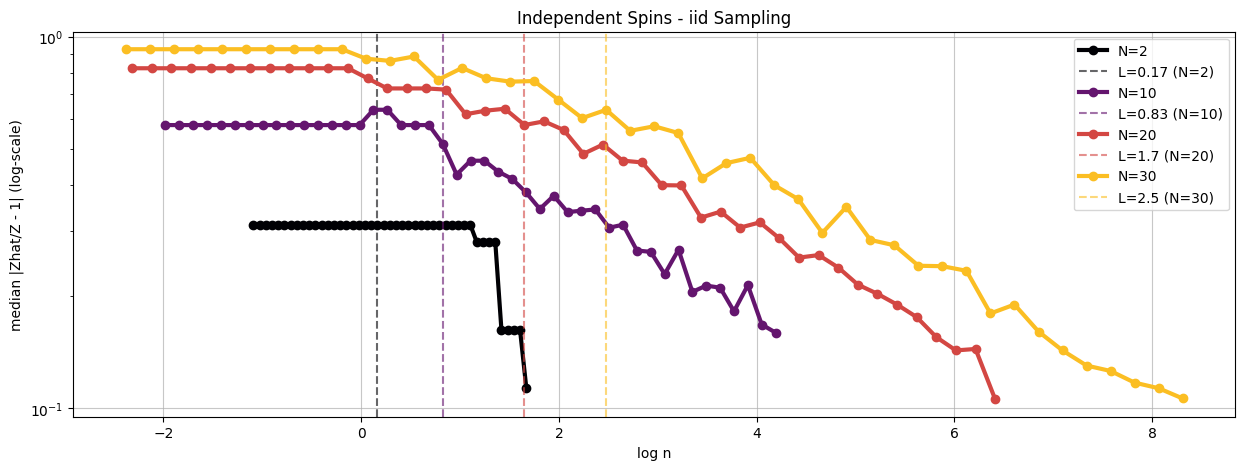

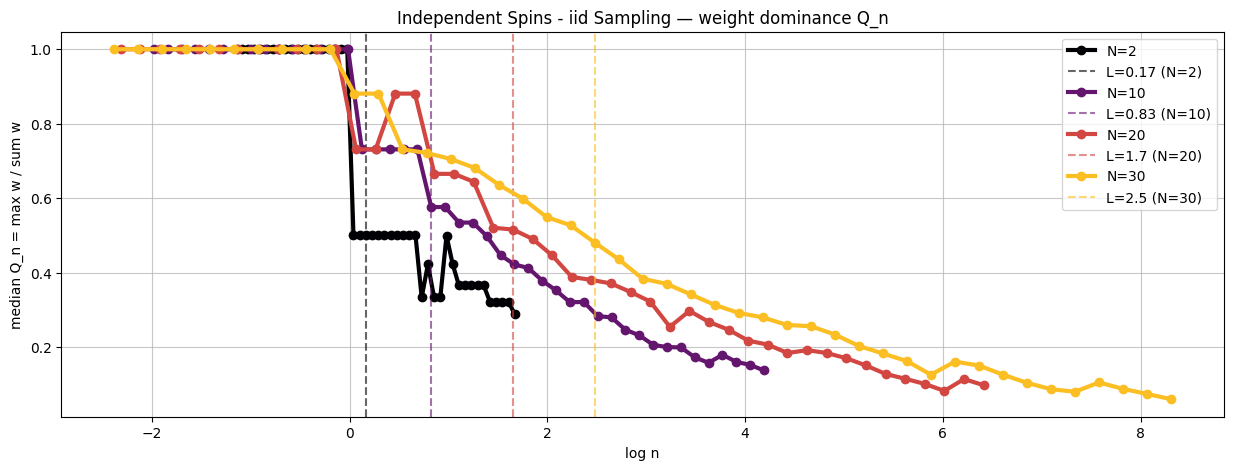

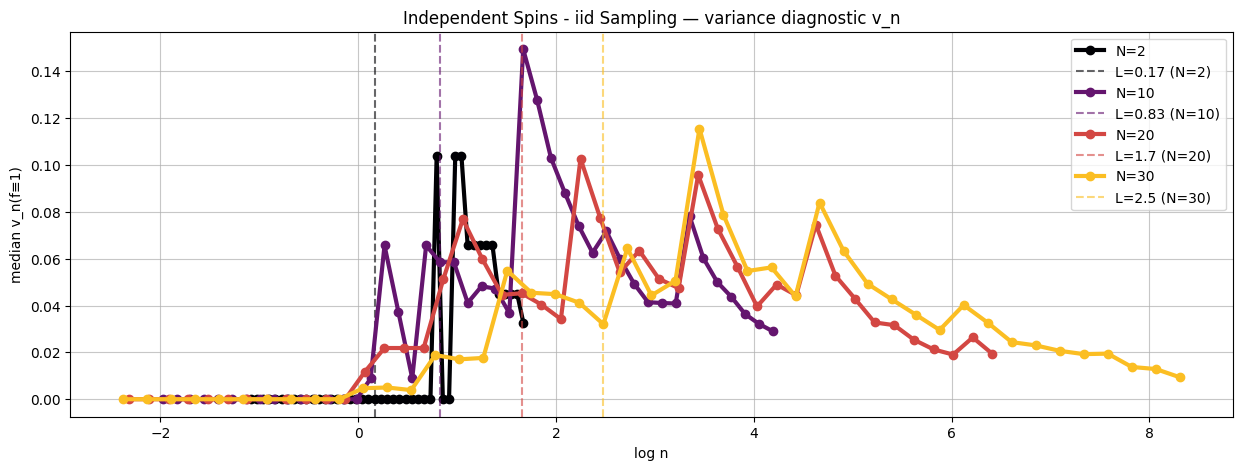

In [ ]:
from Independent_spins.plot import plot_results, plot_compare_L_Lhat, plot_Lhat_error_and_variance, plot_centered_transition
plot_results(results_iid, 'Independent Spins - iid Sampling')

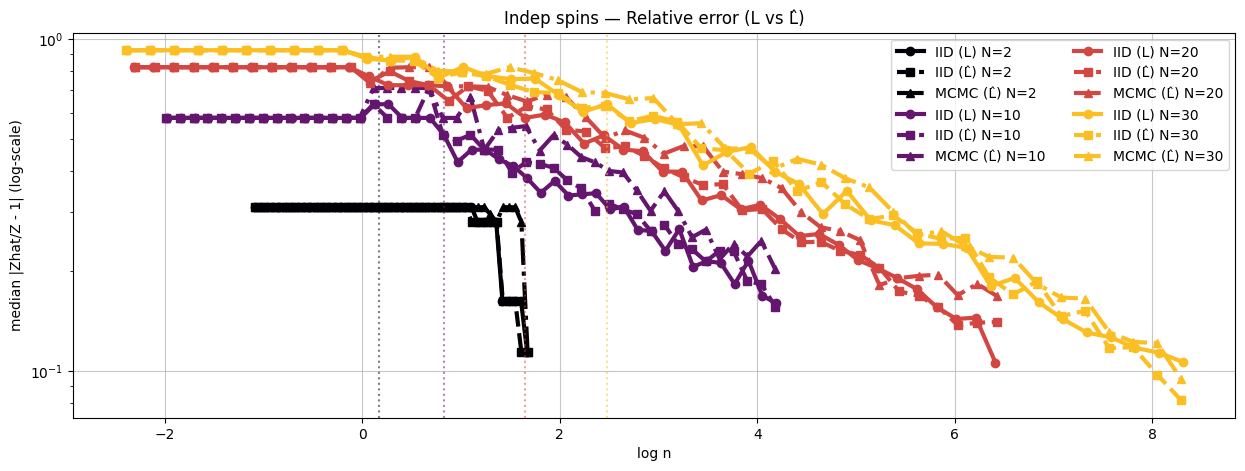

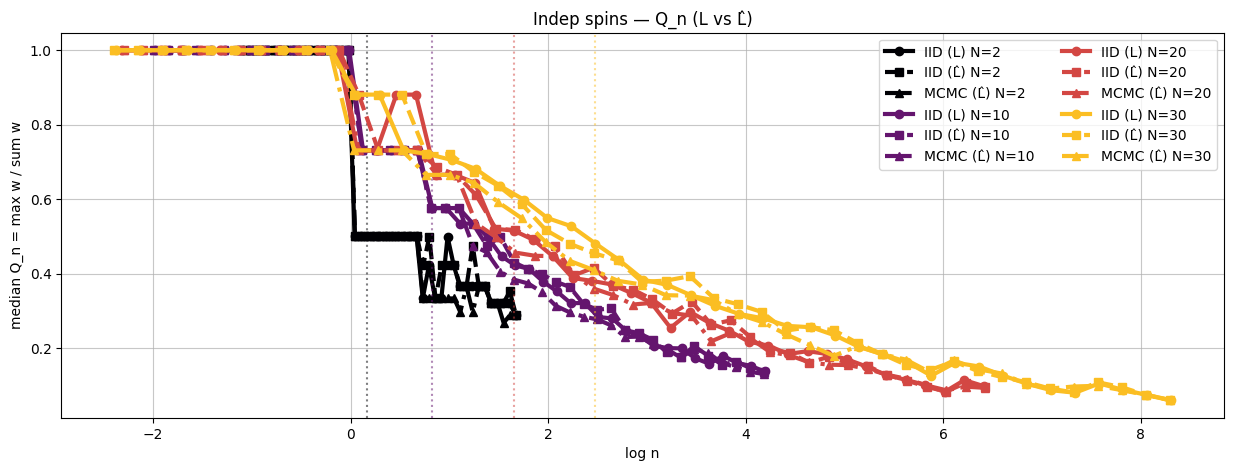

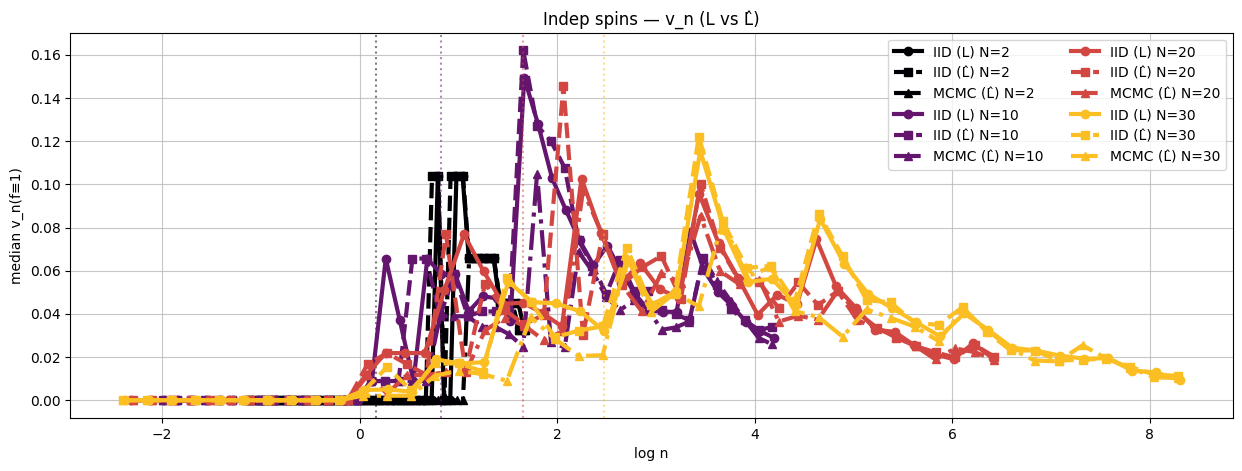

In [4]:
plot_compare_L_Lhat(results_iid, results_iid_Lhat, results_mcmc_Lhat, title='Indep spins')

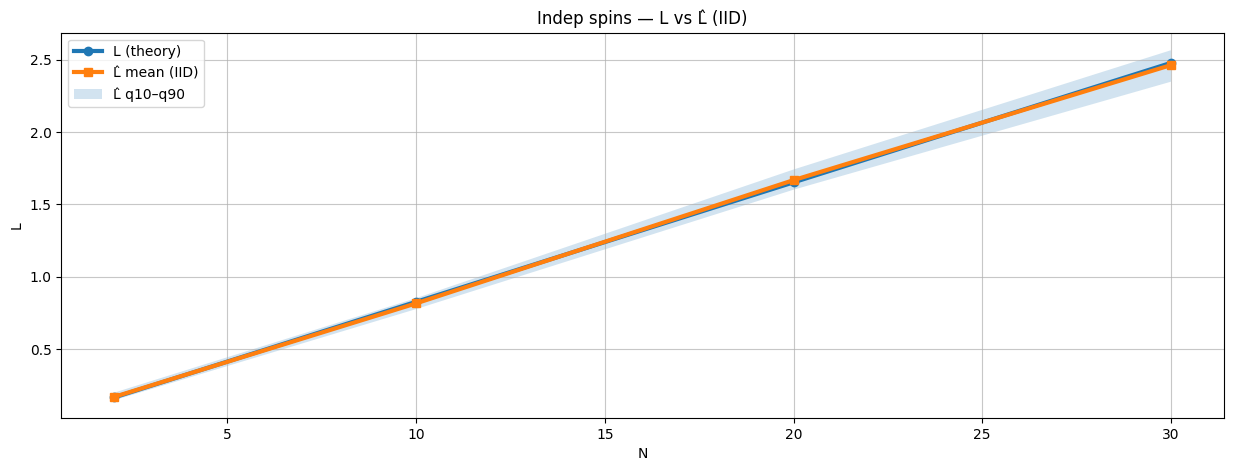

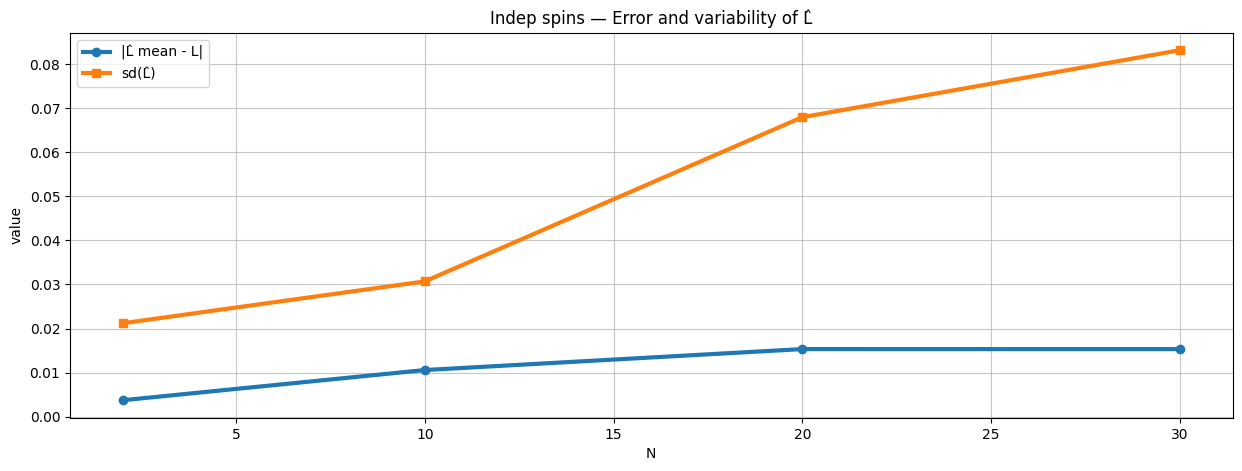

In [5]:
plot_Lhat_error_and_variance(results_L_estimate, "Indep spins")

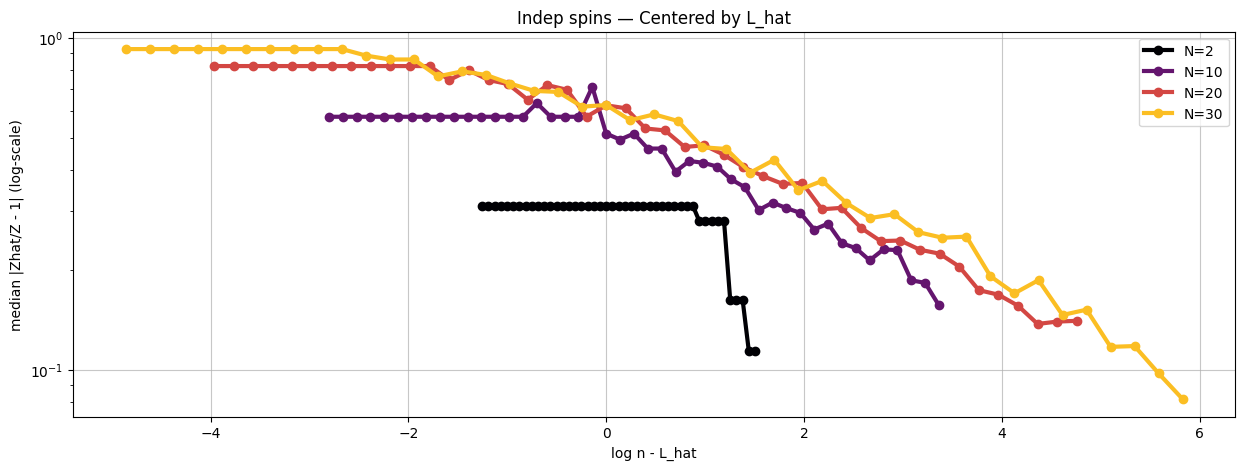

In [6]:
plot_centered_transition(results_iid_Lhat, "Indep spins", center="L_hat")

# Ideal Case  

## Why the Gaussian shift model behaves well theoretically

We consider the Gaussian shift setting
$$
\mu = \mathcal{N}(m, I_d), 
\qquad 
\nu = \mathcal{N}(0, I_d),
$$
with $m = (a,\ldots,a) \in \mathbb{R}^d$.  
In this case, the likelihood ratio is explicit and the Kullback–Leibler divergence is
$$
L = D(\nu \| \mu) = \tfrac12 \|m\|^2 = \tfrac12 d a^2.
$$

This model behaves particularly well from a theoretical point of view for the following reasons.



### 1. The log-likelihood ratio is Gaussian

The log-density ratio is
$$
\log \rho(x) = - m^\top x + \tfrac12 \|m\|^2.
$$

Under $Y \sim \nu = \mathcal{N}(0,I_d)$, we have
$$
m^\top Y \sim \mathcal{N}(0, \|m\|^2),
$$
so
$$
\log \rho(Y)
$$
is itself Gaussian with mean
$$
\mathbb{E}_\nu[\log \rho(Y)] = L
$$
and variance
$$
\mathrm{Var}_\nu(\log \rho(Y)) = \|m\|^2.
$$

Thus, $\log \rho(Y)$ is well concentrated around its mean, with sub-Gaussian tails.



### 2. The divergence has a closed form

In this setting,
$$
L = \tfrac12 d a^2
$$
is explicit. There is no numerical approximation error in estimating $L$, so the theoretical threshold
$$
n \approx \exp(L)
$$
can be compared directly with simulations.



### 3. The transition is clean and controlled

When $n \ll \exp(L)$, the importance sampling estimator is dominated by rare large weights, so
$$
Q_n \approx 1
$$
and the estimator is unstable.

When $n \gg \exp(L)$, these rare events occur frequently enough and the weights distribute more evenly, leading to stabilization of
$$
I_n(1).
$$

Because $\log \rho(Y)$ is Gaussian and well concentrated, this transition occurs sharply around $n \approx \exp(L)$, exactly as predicted by the theory.




In [ ]:
from ideal_case.rare_event import experiment
from ideal_case.plot import plot_results, plot_L_values

results = experiment(
    d=50,
    a_values=[0.3,0.4,0.5,0.6],
    ns=[10**k for k in range(1,7)],
    R=200
)


a=0.3, L=2.25, exp(L)≈9.49e+00
a=0.4, L=4.00, exp(L)≈5.46e+01
a=0.5, L=6.25, exp(L)≈5.18e+02
a=0.6, L=9.00, exp(L)≈8.10e+03


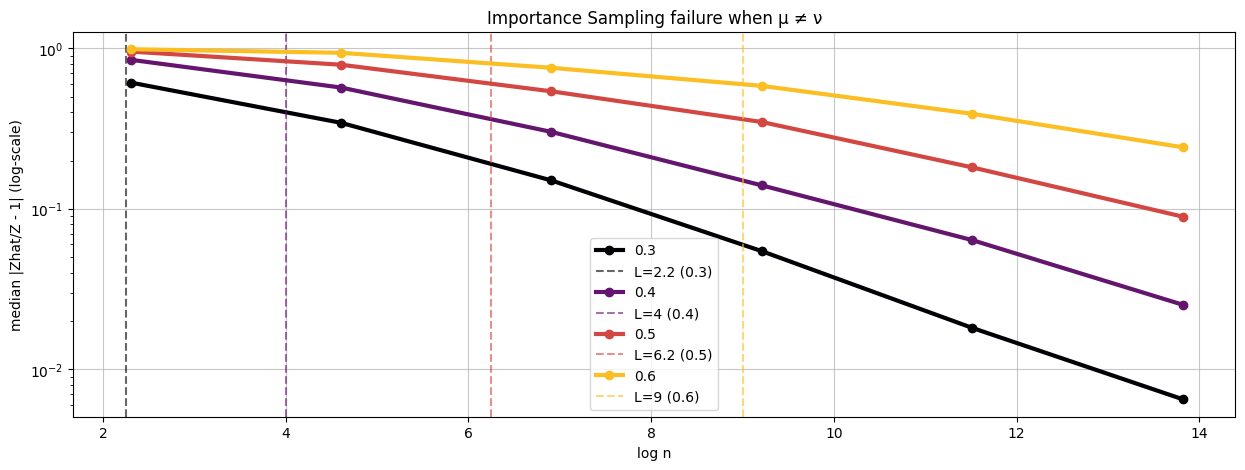

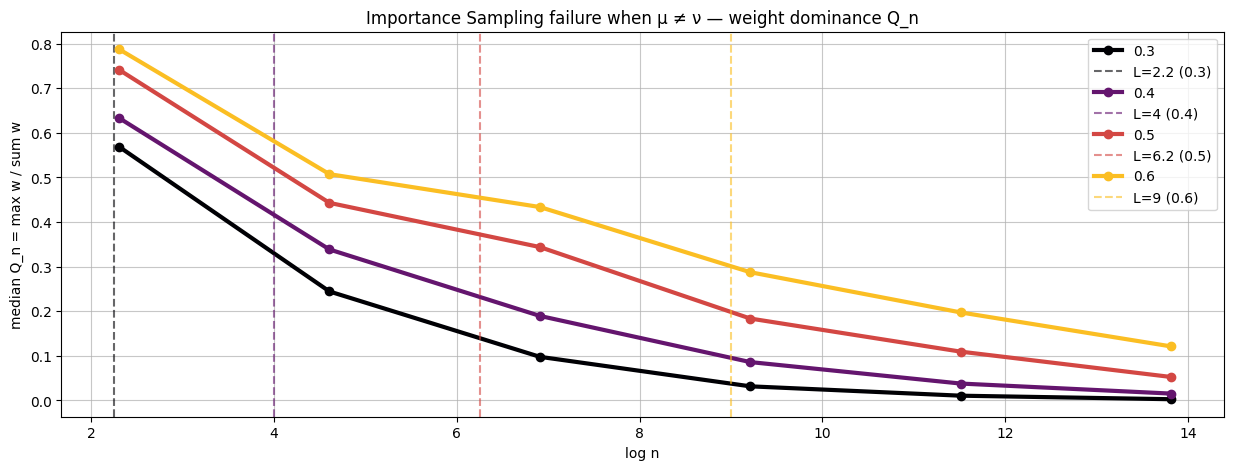

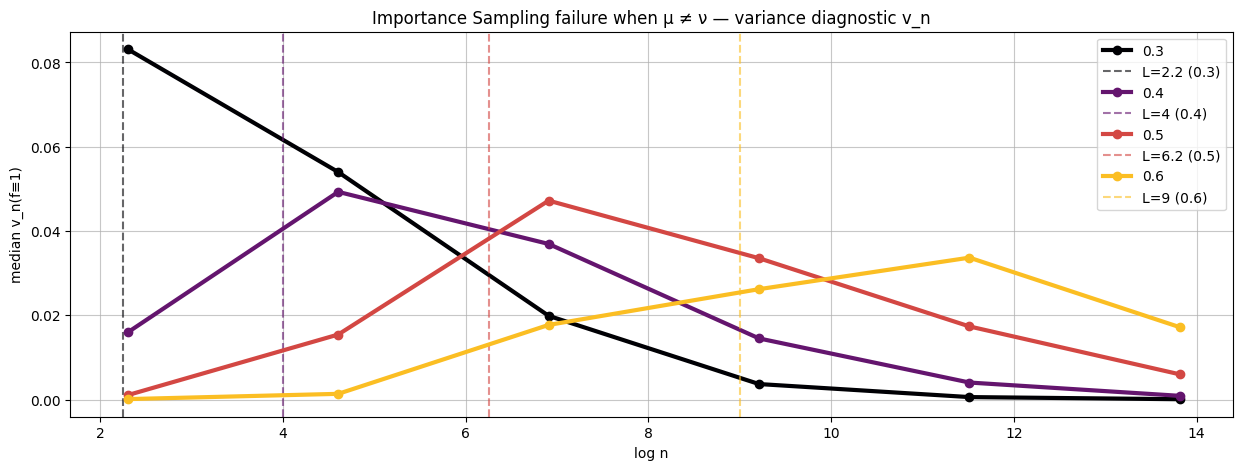

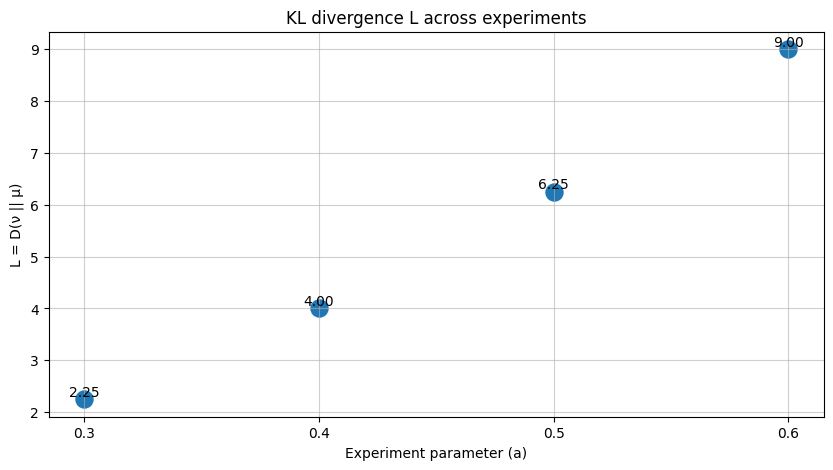

In [4]:
plot_results(results, "Importance Sampling failure when μ ≠ ν")
plot_L_values(results)

# High Limitation: Bi-modale case, rare event

## Why the bimodal Gaussian mixture is a limiting case for the $L$-threshold

We now consider a bimodal Gaussian mixture target
$$
\nu = (1-\varepsilon)\,\mathcal{N}(-m, I_d)
      + \varepsilon\,\mathcal{N}(+m, I_d),
\qquad 
\mu = \mathcal{N}(0, I_d),
$$
with $m = (a,\ldots,a) \in \mathbb{R}^d$ and $0 < \varepsilon \ll 1$.

In this setting, the divergence
$$
L = D(\nu \| \mu)
= \mathbb{E}_\nu[\log \rho(Y)]
$$
no longer admits a closed form and must be estimated numerically.

This model illustrates a limitation of the theoretical threshold
$$
n \approx \exp(L),
$$
because the key quantity $\log \rho(Y)$ is no longer well concentrated.



### 1. Lack of concentration of $\log \rho(Y)$

Under $\nu$, the random variable $\log \rho(Y)$ behaves very differently depending on which component $Y$ comes from:

- With probability approximately $1-\varepsilon$,  
  $Y$ is near $-m$, and $\log \rho(Y)$ takes moderate values.

- With probability $\varepsilon$,  
  $Y$ is near $+m$, and $\log \rho(Y)$ can take extremely large values.

Thus, $\log \rho(Y)$ is typically bimodal or heavy-tailed.  
Its mean
$$
L = \mathbb{E}_\nu[\log \rho(Y)]
$$
is dominated by the majority component and does not fully reflect the presence of rare but extreme values.



### 2. Importance sampling is governed by extremes, not the mean

The performance of importance sampling depends heavily on the largest weights:
$$
Q_n = \frac{\max_i \rho(X_i)}{\sum_i \rho(X_i)}.
$$

When $\varepsilon$ is small, the rare component produces very large weights but is observed only infrequently under $\mu$.  

As a result:

- If no rare high-weight sample is observed, the estimator severely underestimates.
- If a single extreme sample appears, it can dominate the estimate.

Therefore, the behavior of the estimator is driven by tail events rather than by the average value $L$.



### 3. Why the $L$-threshold becomes less informative

The theoretical threshold $n \approx \exp(L)$ relies implicitly on concentration of $\log \rho(Y)$ around its mean.

In the bimodal mixture case:

- $\log \rho(Y)$ is not tightly concentrated.
- Rare extreme values control performance.
- The transition from failure to success is less sharp.
- The empirical threshold may occur significantly to the right of $\exp(L)$.

Thus, while $L$ still measures an average discrepancy between $\nu$ and $\mu$, it no longer fully captures the practical difficulty of importance sampling.


In [9]:
from Mixture_bimodale.Mixture_bimodale import experiment_mixture
import numpy as np

ns = sorted(
    [10**k for k in range(0, 7)]
    + [5*10**k for k in range(0, 6)] 
)
results_mix = experiment_mixture(
    d = 50,
    a_values = [0.4, 0.6, 0.7, 0.8, 1],
    ns = ns,
    R=100,
    seed=1,
    M_L=30_000
)


a=0.4,  L≈0.673,  exp(L)≈1.959e+00
a=0.6,  L≈5.580,  exp(L)≈2.650e+02
a=0.7,  L≈8.823,  exp(L)≈6.789e+03
a=0.8,  L≈12.601,  exp(L)≈2.969e+05
a=1,  L≈21.453,  exp(L)≈2.074e+09


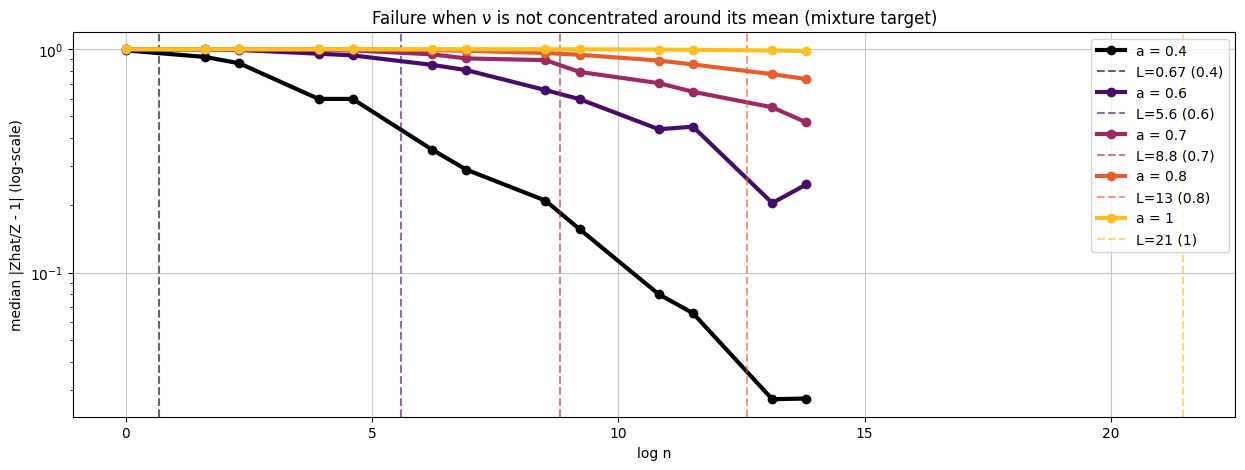

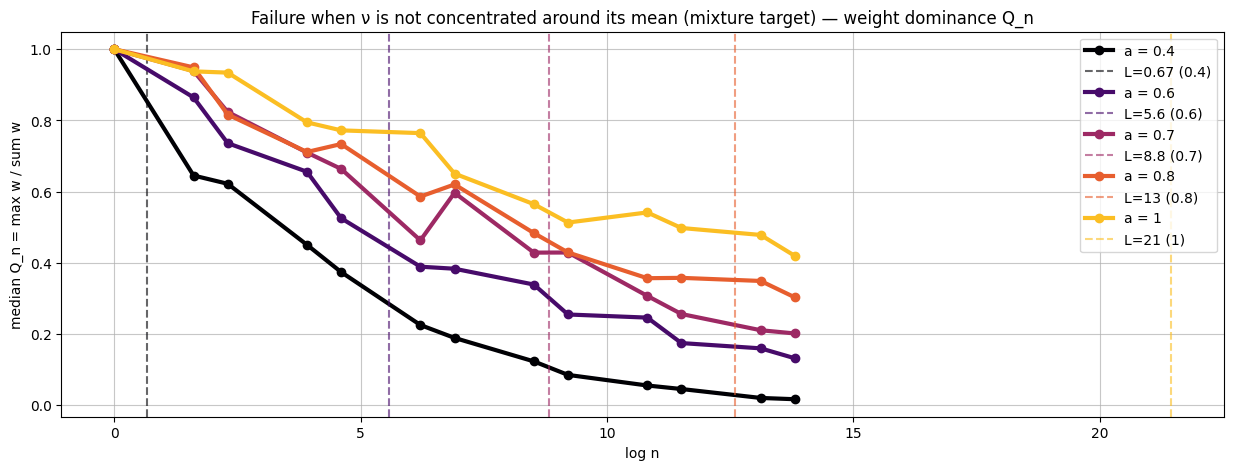

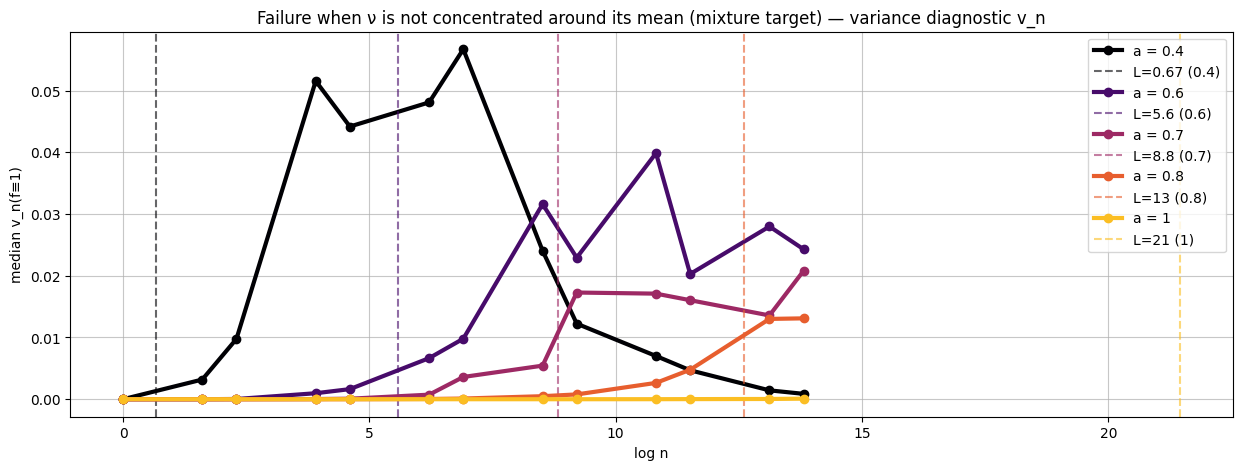

In [11]:
from ideal_case.plot import plot_results

plot_results(results_mix, "Failure when ν is not concentrated around its mean (mixture target)")